In [11]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
trace_num = 2000
cutoff = 0.7e6
numtaps = '101'

trace_path = f'traces_FIR/fc{cutoff}_{numtaps}'

t = np.load(f'{trace_path}/trace.npy')
l = np.load(f'{trace_path}/message.npy')

In [13]:
print("Size of Trace: ", end="")
print(t.shape)
print(t)
print("\nSize of Message: ", end="")
print(l.shape)
print(l)

Size of Trace: (2000, 455000)
[[-0.00298193 -0.00294333 -0.00290481 ...  0.00479795  0.00483918
   0.00488036]
 [-0.00253937 -0.00250466 -0.00247002 ...  0.00506615  0.00510147
   0.00513674]
 [-0.0027927  -0.00276282 -0.00273302 ...  0.00308932  0.00306619
   0.00304297]
 ...
 [-0.00291784 -0.00288282 -0.00284788 ...  0.0029698   0.00294235
   0.00291478]
 [-0.0038701  -0.00381482 -0.00375964 ...  0.0066231   0.006704
   0.00678489]
 [-0.00336345 -0.00331192 -0.00326049 ...  0.00678785  0.00688098
   0.00697412]]

Size of Message: (2000, 32)
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]


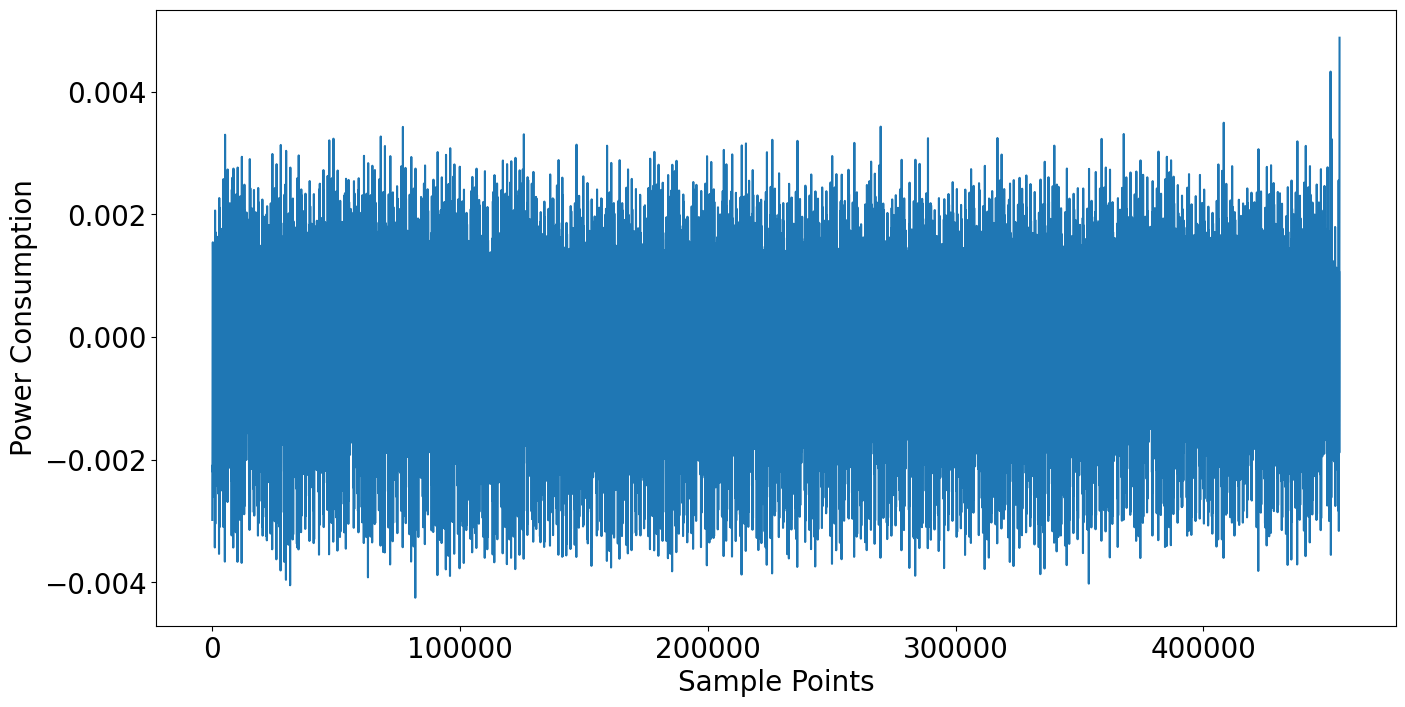

In [14]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(t[0])

In [15]:
mean_t = np.mean(t, axis=0)
print(mean_t)

[-0.00299086 -0.00295106 -0.00291135 ...  0.00522235  0.00526616
  0.00530993]


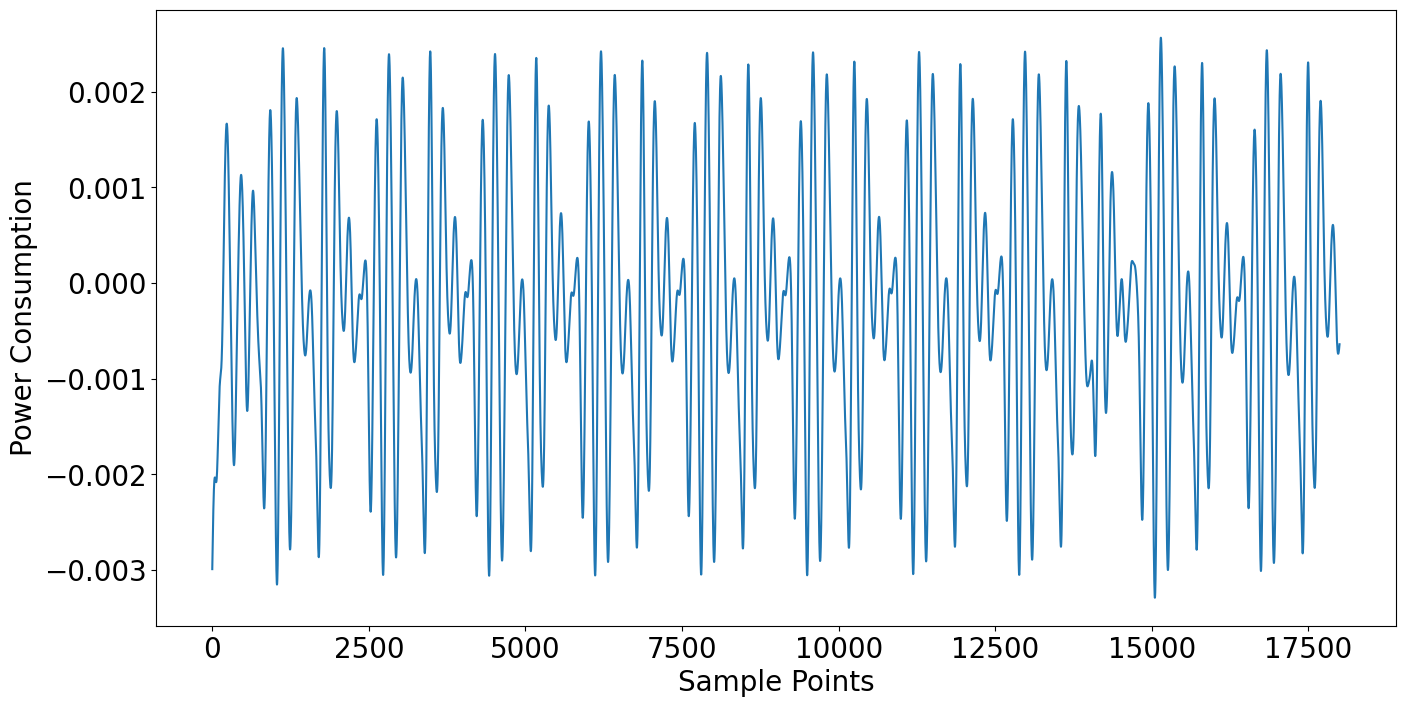

In [16]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(mean_t[:18000])

In [17]:
trace_length = t.shape[1]
print(trace_length)

455000


In [18]:
# 使用 unpackbits 轉換成 bits，並指定 bitorder='little' 使 LSB 在前
bits = np.unpackbits(l.astype(np.uint8), axis=1, bitorder='little')  # 結果形狀: (2000, 256)
h = bits * 16

print(l.shape)
print(bits.shape)
print(h.shape)
print(l)
print(h)

(2000, 32)
(2000, 256)
(2000, 256)
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]
[[ 0  0 16 ...  0  0  0]
 [ 0  0 16 ... 16  0  0]
 [ 0 16 16 ... 16 16  0]
 ...
 [16  0 16 ... 16 16  0]
 [ 0  0 16 ...  0  0 16]
 [16 16  0 ...  0 16  0]]


In [19]:
print("設定參數")
var = np.zeros((256, trace_length))    # 存16bytes分群後平均的變異數
avg = np.zeros((256, trace_length))    # 存16bytes分群後變異數的平均
SNR = np.zeros((256, trace_length))    # 存16bytes的SNR
avg_diff_HW = np.zeros((256, 2, trace_length)) # 存16bytes的九群的平均
var_diff_HW = np.zeros((256, 2, trace_length)) # 存16bytes的九群的變異數
count = np.zeros((256, 2), dtype=int)                    # 存 HW=0 ~ HW=8各有多少個

print("計算開始")
for b in range(256):                          # 16 bytes做16次
    t_sum = np.zeros((2, trace_length))      # 分成9群
    t2_sum = np.zeros((2, trace_length))
    avg_t = np.zeros((2, trace_length))
    avg2_t = np.zeros((2, trace_length))
    var_t = np.zeros((2, trace_length))
    
    for j in range(trace_num):               # 對每一行(每一byte)的不同 HW 做分群
        target = 1 if h[j, b] == 16 else 0   # 取得第j行(每一byte)所有HW，target會得到介於0到8的數值
        t_sum[target] += t[j]                # 將第j條波形的5000個樣本點加總到對應的 target index 那格中
        t2_sum[target] += t[j] ** 2
        count[b][target] += 1                # 九格分別代表 HW 0~8 共有多少條trace的
        
    prob = count[b] / trace_num              # 每一Byte"實際上"出現的機率
    
    for j in range(2):
        avg_t[j] = t_sum[j] / count[b][j]                     # 計算分群的平均
        var_t[j] = t2_sum[j] / count[b][j] - avg_t[j] ** 2    # 計算分群的變異數
    
    # 下面計算分群後平均的變異數; 平方的平均 - 平均的平方
    var[b] = sum((avg_t ** 2) * prob.reshape(2, 1)) - sum(avg_t * prob.reshape(2, 1)) ** 2
    avg[b] = sum(var_t * prob.reshape(2, 1)) # 計算分群變異數的平均
    
    avg_diff_HW[b] = avg_t
    var_diff_HW[b] = var_t
    print(b)
print("計算結束")

設定參數
計算開始
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
計算結束


In [20]:
SNR = var / avg
print("SNR:")
print("Size=", SNR.shape, sep="")
for j in range(256):
    print("第 {:2} byte ".format(j), end="")
    print(SNR[j])

SNR:
Size=(256, 455000)
第  0 byte [2.76750710e-04 2.74988471e-04 2.73128479e-04 ... 3.93773878e-06
 3.68092628e-06 3.44650121e-06]
第  1 byte [0.00154805 0.00156436 0.00158159 ... 0.00082406 0.00082053 0.00081718]
第  2 byte [2.22397695e-04 2.25049815e-04 2.27861878e-04 ... 2.30356551e-05
 2.27610861e-05 2.25039473e-05]
第  3 byte [3.58524928e-06 3.75455582e-06 3.93757798e-06 ... 7.07165066e-04
 7.03778711e-04 7.00569958e-04]
第  4 byte [2.85808581e-05 2.77994569e-05 2.69851382e-05 ... 8.61263188e-08
 1.14605230e-07 1.45266674e-07]
第  5 byte [1.90257544e-06 2.26785070e-06 2.68813305e-06 ... 4.41370776e-04
 4.39121546e-04 4.36988418e-04]
第  6 byte [2.59590261e-03 2.58652037e-03 2.57654597e-03 ... 3.34321982e-05
 3.34323557e-05 3.34328787e-05]
第  7 byte [0.00318136 0.00318291 0.00318444 ... 0.0007699  0.00077228 0.00077452]
第  8 byte [2.16733684e-05 2.10599929e-05 2.04217240e-05 ... 1.37983734e-04
 1.39572015e-04 1.41077335e-04]
第  9 byte [0.00011485 0.00011673 0.00011874 ... 0.00125978 0.00

In [21]:
# 對每一列 (axis=1) 找出最大值的索引
snr = np.argmax(SNR, axis=1)

print("snr shape:", snr.shape)   # (256,)
print("snr:", snr)

snr shape: (256,)
snr: [  1707   3399   5090   6782   8476  10171  11865  13556  15719  17413
  19106  20803  22495  24186  25878  27570  29737  31434  33125  34815
  36508  38289  39896  41590  43754  45446  47137  48833  50528  52221
  53912  55603  57768  59465  61158  62851  64542  66321  68014  69620
  71788  73482  75171  76864  78557  80252  81946  83638  85801  87495
  89188  90884  92577  94268  96046  97651  99819 101515 103206 104899
 106590 108283 109977 111672 113835 115528 117219 118914 120608 122303
 123993 125685 127849 129545 131239 132932 134624 136316 138096 139702
 141869 143563 145253 146946 148638 150333 152027 153719 155883 157576
 159269 160965 162658 164350 166040 167733 169900 171596 173287 174980
 176671 178364 180058 181753 183918 185610 187300 188995 190689 192384
 194075 195766 197931 199626 201320 203014 204705 206483 208177 209869
 211950 213644 215335 217115 218808 220414 222108 223801 225964 227658
 229350 231046 232739 234432 236121 237814 239981 2416

In [22]:
import numpy as np

# ---------- 已知參數 ----------
trace_num = t.shape[0]           # trace 总数
L         = t.shape[1]         # 每条 trace 的长度
N_POI     = 256            # 总共 256 个 POI
N_BYTE    = 32             # 分成 32 个 byte（每 byte 下有 8 个 POI）
POI_PER_BYTE = 8           # 每组 8 个 POI

WIN = 300                  # 每个 POI 要取 ±300 样点
WIN_SIZE = 2 * WIN + 1     # = 601

# 假设 snr_idx 是一个长度为 256 的 numpy 数组，
# 里面存放了每个 POI 在 trace 中的全局索引
# 比如：snr_idx = np.array([... 256 个整数 ...])
snr_idx = np.asarray(snr)   # 你之前计算出的 256 个 POI 全局索引

# t 的形状应该是 (2000, 455000)，l 的形状是 (2000, 32)
# t[tr] 表示第 tr 条 trace；l[tr, byte] 是第 tr 条 trace 下第 byte 的标签（一个 0~255 的值）

# ---------- 步骤 1：先从每条 trace 上针对所有 256 个 POI，截取 ±300 采样点窗口 ----------
# 我们把它放到一个中间数组 W，形状 (trace_num, 256, 601)
W = np.zeros((trace_num, N_POI, WIN_SIZE), dtype=t.dtype)

for tr in range(trace_num):
    trace = t[tr]   # 长度 = L
    for p in range(N_POI):
        idx = int(snr_idx[p])
        start = idx - WIN
        end   = idx + WIN + 1   # Python slice 不包含 end，本质上拿到的元素数量 = WIN_SIZE
        
        window = trace[start : end]
        
        # 此时 window 应该总长度为 601
        if window.shape[0] != WIN_SIZE:
            raise ValueError(f"第 {tr} 条 trace，第 {p} 个 POI 切片后长度 = {window.shape[0]}，理应 = {WIN_SIZE}。")
        
        W[tr, p, :] = window
    # print(tr)

# ---------- 步骤 2：把 256 个 POI 分成 32 组（每组 8 个 POI），然后把同一条 trace 下的“8 个 601 向量”拼接成长度 4808 ----------

# 先准备一个索引列表，切分成 32 份
# 比如： group_indices[0] = [0,1,2,3,4,5,6,7]， group_indices[1] = [8..15]，…… 以此类推
group_indices = [ list(range(byte*POI_PER_BYTE, (byte+1)*POI_PER_BYTE)) for byte in range(N_BYTE) ]
# group_indices 长度 = 32，每个元素是一个长度为 8 的 Python list

# 定义 X_final 存最终结果
# 如果你想得到 (2000, 32, 4808)，就：
X_final = np.zeros((trace_num, N_BYTE, POI_PER_BYTE * WIN_SIZE), dtype=t.dtype)
# 对应的标签 y 形状： (trace_num, 32)
Y_label = np.zeros((trace_num, N_BYTE), dtype=l.dtype)

for tr in range(trace_num):
    for byte in range(N_BYTE):
        poi_list = group_indices[byte]  # 这是一组 8 个 POI 的下标
        # 从 W[tr, :, :] 中抽取这 8 个 POI 的 window，然后沿最后一维 concat
        windows_to_concat = [ W[tr, p, :] for p in poi_list ]   # 列表里装 8 个形状为 (601,) 的 array
        X_seg = np.concatenate(windows_to_concat, axis=0)        # 结果长度 = 8 × 601 = 4808
        
        # 放回 X_final
        X_final[tr, byte, :] = X_seg
        # 标签直接来源于原始 l
        Y_label[tr, byte]  = l[tr, byte]
    # print(tr)
# 最终：
#   X_final.shape = (2000, 32, 4808)
#   Y_label.shape = (2000, 32)

# 如果你要做「每个 byte 作为一次样本」的训练，就可以把它 reshape 成 (2000*32, 4808)，对应标签也展平成 (2000*32,)
X_flat = X_final.reshape(trace_num * N_BYTE, POI_PER_BYTE * WIN_SIZE)
Y_flat = Y_label.reshape(trace_num * N_BYTE)

print("X_flat.shape =", X_flat.shape)   # 应该是 (64000, 4808)
print("Y_flat.shape =", Y_flat.shape)   # 应该是 (64000,)


X_flat.shape = (64000, 4808)
Y_flat.shape = (64000,)


In [23]:
print('size of new_trace:', X_flat.shape)
print(X_flat[0])
print('size of new_label:', Y_flat.shape)
print(Y_flat[2])

size of new_trace: (64000, 4808)
[0.00092114 0.0008951  0.00086876 ... 0.00202672 0.00202342 0.00201911]
size of new_label: (64000,)
11.0


In [24]:
print(t[0, 1394:1394+3])

[0.00122891 0.00120742 0.00118555]


#### check

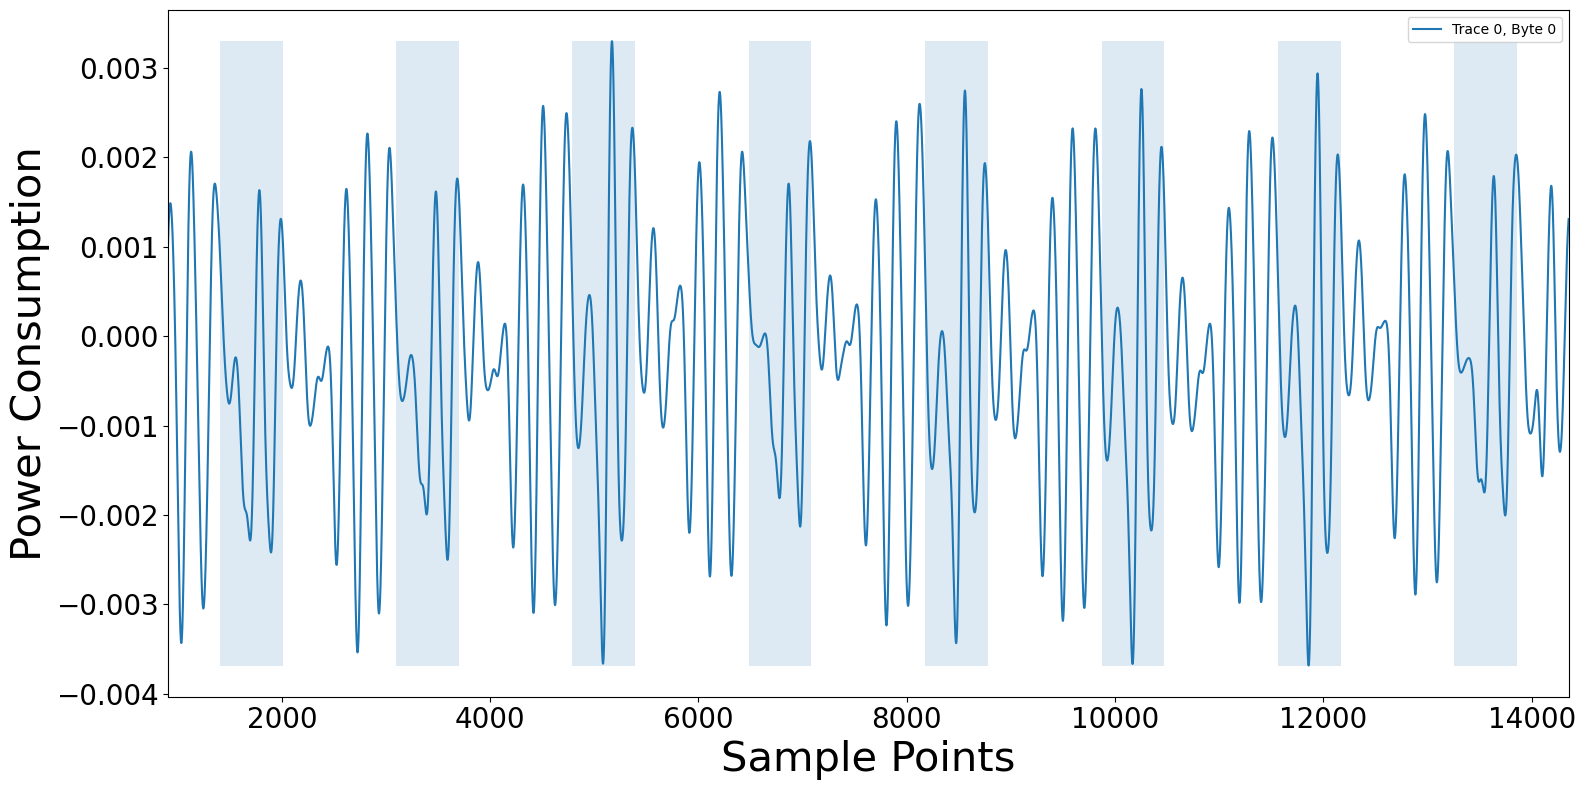

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 假设已定义：t（shape=(trace_num, L)），snr_idx（长度 ≥ 256），WIN，以及你要看的 trace_id, byte
trace_id   = 0
byte       = 0
WIN        = 300
extra_pre  = 500   # 在“第一个 POI - WIN”之前再扩 500 点
extra_post = 500   # 在“最后一个 POI + WIN”之后再扩 500 点

# 取出这一组 8 个 POI 的全局索引
poi_global = snr_idx[byte*8:(byte+1)*8]

# 计算 segment 的起止（全局索引）
first_poi = int(poi_global[0])
last_poi  = int(poi_global[-1])

seg_start = max(first_poi - WIN - extra_pre, 0)
seg_end   = min(last_poi + WIN + extra_post, t.shape[1])
segment_length = seg_end - seg_start

# 切出这段数据，并准备全局 x 轴索引
seg = t[trace_id, seg_start:seg_end]
x   = np.arange(seg_start, seg_end)

# 画图
plt.figure(figsize=(16, 8))
plt.plot(x, seg, color="C0", label=f"Trace {trace_id}, Byte {byte}")

# 高亮每个 POI ±WIN 区域，统一用同一颜色
for idx in poi_global:
    start_rect = idx - WIN
    plt.gca().add_patch(
        Rectangle(
            (start_rect, seg.min()),
            width=2*WIN+1,
            height=seg.max() - seg.min(),
            color="C0",
            alpha=0.15,
            lw=0
        )
    )

# 设置 x 轴范围为全局索引区间
plt.xlim(seg_start, seg_end)
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('figure/trace_preprocess_split/poi_location.png', dpi=200, bbox_inches='tight')
plt.show()


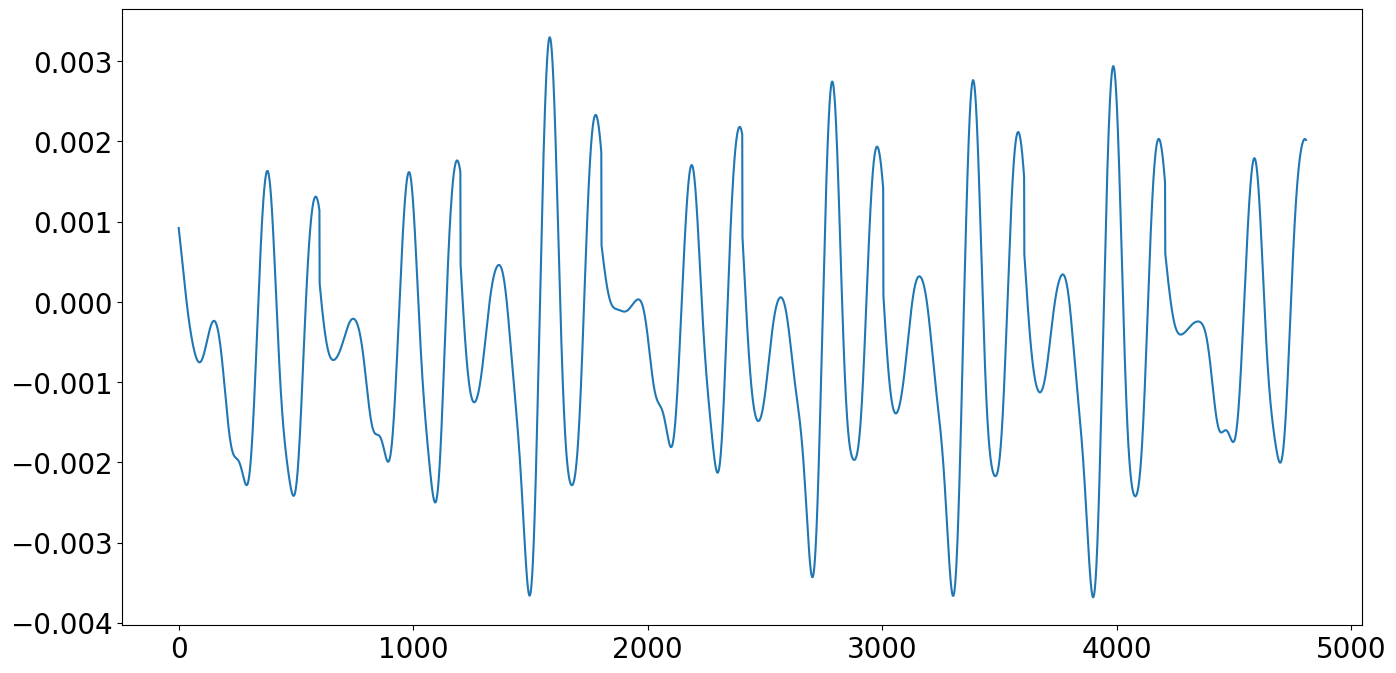

In [26]:
plt.figure(figsize=(16, 8))
plt.plot(X_flat[0])

size of new_trace: (64000, 4808)
size of new_label: (64000,)


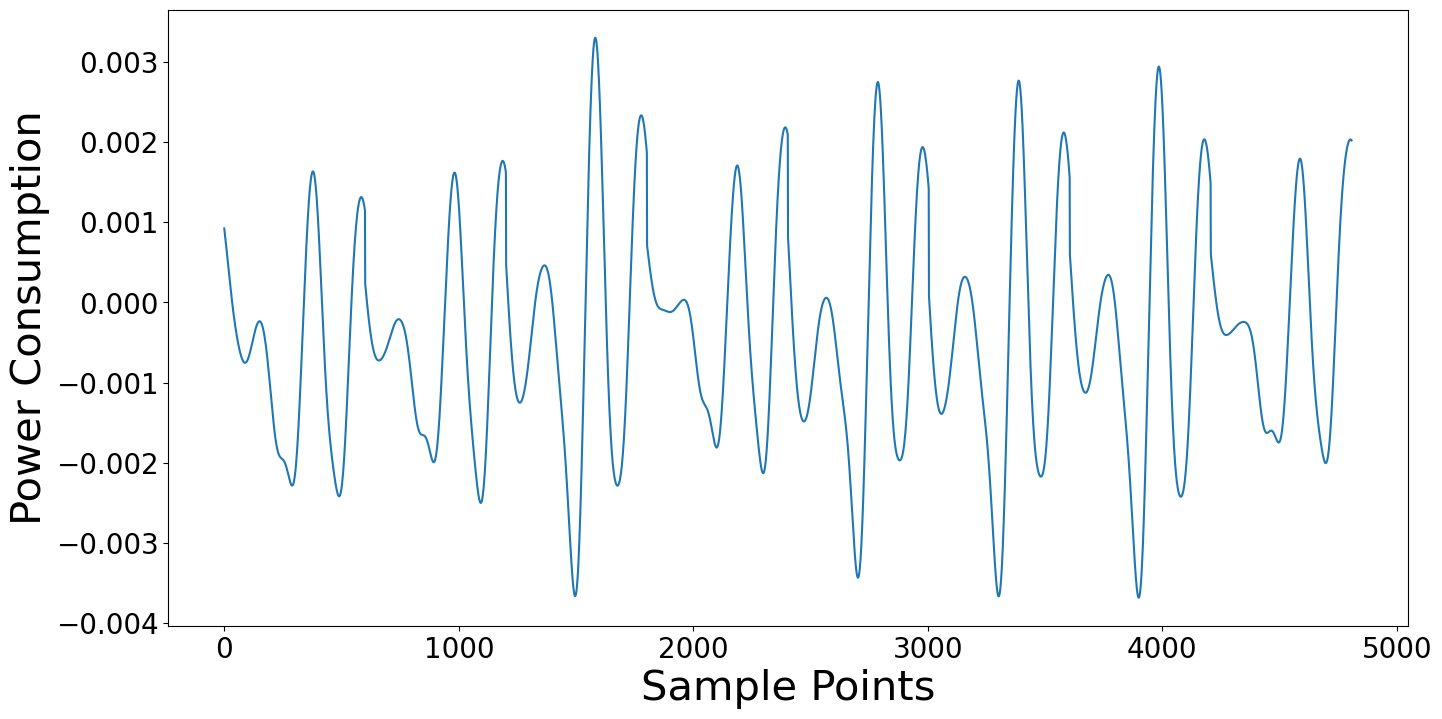

In [27]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)

print('size of new_trace:', X_flat.shape)
print('size of new_label:', Y_flat.shape)
plt.plot(X_flat[0])

# plt.savefig('figure/trace_preprocess_split/poi_result_of_new_single_trace.png', dpi=200, bbox_inches='tight')


size of new_trace: (64000, 4808)
size of new_label: (64000,)


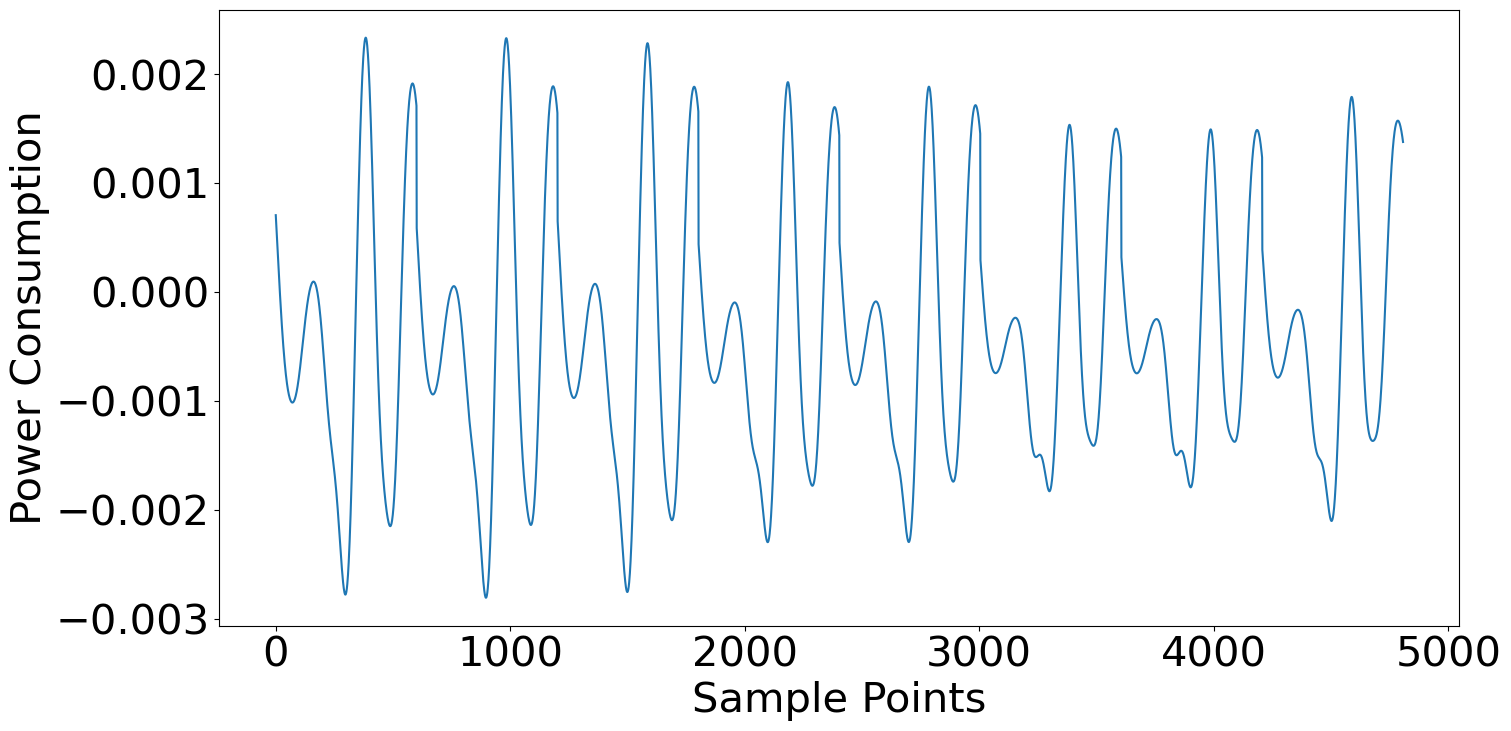

In [28]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=30)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=30)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)

print('size of new_trace:', X_flat.shape)
print('size of new_label:', Y_flat.shape)
plt.plot(np.mean(X_flat, axis=0))

# plt.savefig('figure/trace_preprocess_org/result_of_new__mean_trace.png', dpi=200, bbox_inches='tight')

In [30]:
trace_path = f'traces_FIR_train/fc{cutoff}_{numtaps}'

if not os.path.exists(trace_path):
    os.makedirs(trace_path)
    print(f"已創建目錄: {trace_path}")


np.save(f'{trace_path}/trace.npy', X_flat)
np.save(f'{trace_path}/label.npy', Y_flat)
print('done')

已創建目錄: traces_FIR_train/fc700000.0_101
done
